In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape data for CNN: (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Normalize pixel values from 0-255 to 0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', #otherwise use sparse_categorical_crossentropy without hot encode
    metrics=['accuracy']
)

# Train model
model.fit(
    x_train,
    y_train,
    epochs=1,
    batch_size=128,
    validation_split=0.1
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 113ms/step - accuracy: 0.8928 - loss: 0.3446 - val_accuracy: 0.9813 - val_loss: 0.0634
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9795 - loss: 0.0650
Test Loss: 0.06497079133987427
Test Accuracy: 0.9794999957084656


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted:  0
Actual:  0


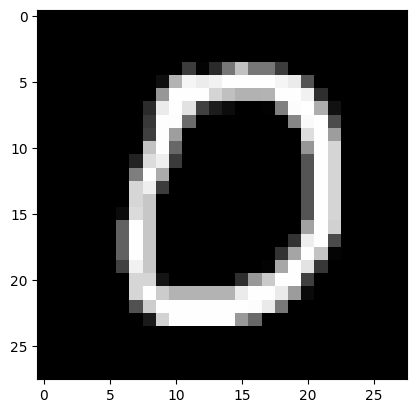

In [ ]:
import matplotlib.pyplot as plt
pred = model.predict(x_test[10:11])

plt.imshow(x_test[10].reshape(28,28),cmap='grey')
print("Predicted: ",pred.argmax())
print("Actual: ",y_test[10].argmax())